# **WSINDy for ODEs: Examples**

This notebook illustrates the Weak SINDy algorithm being applied to ODE systems.

---

The examples are:
- the logistic equation
- the Lotka-Volterra equations
- the Lorenz '63 equations


In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from IPython.display import display,Math

from wsindy_ode import *

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

In [30]:
# Plot settings
import matplotlib

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100
#plt.rcParams['figure.dpi'] = 300

matplotlib.rc('xtick', labelsize=10, direction='out')
matplotlib.rc('ytick', labelsize=10, direction='out')

Utilities and helpers...

In [69]:
def to_torch_solution(sol):
  return [torch.tensor(ui, dtype=torch.float64) for ui in sol.y]

def add_noise_to_states(states, noise):
  if noise == 0:
    return states
  return [add_noise(ui, noise) for ui in states]

def plot_states(t, states, names, title):
  plt.figure(figsize=(7,3))
  for ui,name in zip(states,names):
    plt.plot(t, ui, label='$' + name + '(t)$')
  plt.xlabel('$t$')
  plt.title(title)
  plt.grid(True, alpha=0.3)
  plt.legend(loc='upper left')
  plt.show()

def fit_wsindy_system(states, t, names, beta, m, p, s, Lambda=1e-3, rescale=True, verbosity=False):
  alpha = [[1], [0]]

  models = []
  odes = []
  
  for i,Ui in enumerate(states):
    aux_inds = [j for j in range(len(states)) if j != i]
    V = [states[j] for j in aux_inds]
    local_names = [names[i]] + [names[j] for j in aux_inds]

    model = WSINDy(Ui, alpha, beta, t, V=V, names=local_names,
                   m=m, p=p, s=s, verbosity=verbosity, rescale=rescale)

    [G,powers,derivs,rhs_names] = model.create_default_library()
    display(Math(r'\Theta_{' + names[i] + r'}=' + r'\{' + r', \, '.join(rhs_names) + r'\}'))

    model.build_lhs(names[i] + model.derivative_names[0])
    model.set_library(G, powers, derivs, rhs_names)

    _ = model.MSTLS(Lambda=Lambda)
    model.print_report()

    models.append(model)
    odes.append(symbolic_ode(model.lhs_name, model.rhs_names, model.coeffs))

  for ode in odes:
    display(Math(ode))
  return models,odes

## **LOGISTIC EQUATION**

This example is
\begin{align*}
  \dot u = r u\left(1 - \frac{u}{K}\right),
  \quad \text{with} \quad
  \begin{cases}
    r = 1.5,
    \\
    K=2.
  \end{cases}
\end{align*}

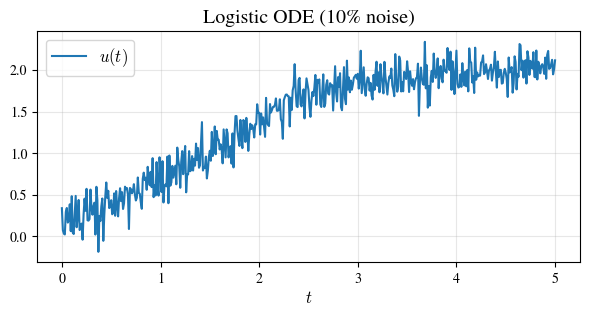

In [70]:
r = 1.5
K = 2.0
t_np = np.linspace(0, 5, 501)

def logistic_rhs(t, u):
  return r*u*(1 - u/K)

sol = solve_ivp(logistic_rhs, (t_np[0], t_np[-1]), [0.2], t_eval=t_np, rtol=1e-12, atol=1e-12, method='DOP853')

noise = 0.10
t = torch.tensor(t_np, dtype=torch.float64)
[u] = add_noise_to_states(to_torch_solution(sol), noise)

plot_states(t_np, [u], ['u'], f'Logistic ODE ({noise*100:.0f}% noise)')

In [71]:
beta = [[0], [1], [2]]

[model, ode] = fit_wsindy_system([u], t, ['u'], beta, m=[16], p=[8], s=[5], Lambda=1e-1)

100%|██████████| 1/1 [00:00<00:00, 995.33it/s]


<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [16]
p = [8]
s = [5]
yt = 6.250
yu = 0.736
Aux. scales = []

LIBRARY
Num. query points = 94
Num. terms = 3
cond(G) = 3.332e+01

RESULTS
ODE: u_{t} = + 1.52(u) - 0.75(u^2)
Nonzero terms = 2
Rel. L2 error = 0.846
R^2 = 0.104
Lambda = 1.000e-01
Loss = 0.712


<IPython.core.display.Math object>

## **LOTKA-VOLTERRA**

This pup is:
\begin{align*}
  \begin{cases}
    \dot{x} = ax - bxy,\\
    \dot{y} = -cy + dxy,
  \end{cases}
  \quad \text{with} \quad
  \begin{cases}
    a = 1.5,
    \\
    b = 1,
    \\
    c = 3,
    \\
    d = 1.
  \end{cases}
\end{align*}

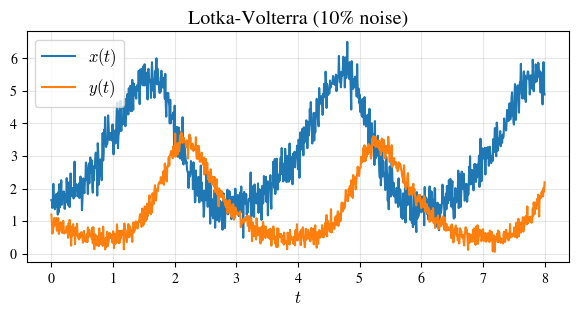

In [72]:
a = 1.5
b = 1.0
c = 3.0
d = 1.0
t_np = np.linspace(0, 8, 1001)

def lotka_volterra_rhs(t, z):
  x,y = z
  return [a*x - b*x*y,
          -c*y + d*x*y]

sol = solve_ivp(lotka_volterra_rhs, (t_np[0], t_np[-1]), [1.5, 1.0], t_eval=t_np,
                rtol=1e-12, atol=1e-12, method='DOP853')

noise = 0.10
t = torch.tensor(t_np, dtype=torch.float64)
[x,y] = add_noise_to_states(to_torch_solution(sol), noise)

plot_states(t_np, [x,y], ['x','y'], f'Lotka-Volterra ({noise*100:.0f}% noise)')

In [73]:
beta = [[0,0],
        [1,0],
        [0,1],
        [2,0],
        [1,1],
        [0,2]]

[model, ode] = fit_wsindy_system([x,y], t, ['x','y'], beta, m=[20], p=[10], s=[5], Lambda=1e-1)

100%|██████████| 1/1 [00:00<00:00, 675.09it/s]


<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [20]
p = [10]
s = [5]
yt = 6.250
yu = 0.472
Aux. scales = [0.607]

LIBRARY
Num. query points = 193
Num. terms = 6
cond(G) = 1.623e+02

RESULTS
ODE: x_{t} = + 1.48(x) - 0.99(x y)
Nonzero terms = 2
Rel. L2 error = 0.522
R^2 = 0.722
Lambda = 1.000e-01
Loss = 0.360


100%|██████████| 1/1 [00:00<00:00, 598.93it/s]


<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [20]
p = [10]
s = [5]
yt = 6.250
yu = 0.607
Aux. scales = [0.472]

LIBRARY
Num. query points = 193
Num. terms = 6
cond(G) = 1.623e+02

RESULTS
ODE: y_{t} = - 3.02(y) + 1.00(y x)
Nonzero terms = 2
Rel. L2 error = 0.364
R^2 = 0.868
Lambda = 1.000e-01
Loss = 0.356


<IPython.core.display.Math object>

<IPython.core.display.Math object>

## **LORENZ '63**

The all-time classic:
\begin{align*}
  \begin{cases}
    \dot{x} = \sigma(y-x),\\
    \dot{y} = x(\rho-z)-y,\\
    \dot{z} = xy-\beta z,
  \end{cases}
  \quad \text{with} \quad
  \begin{cases}
    \sigma = 10,
    \\
    \rho = 28,
    \\
    \beta = 8/3.
  \end{cases}
\end{align*}

For each state equation below, the library is ordered with the left-hand-side state first and the remaining states as auxiliaries.

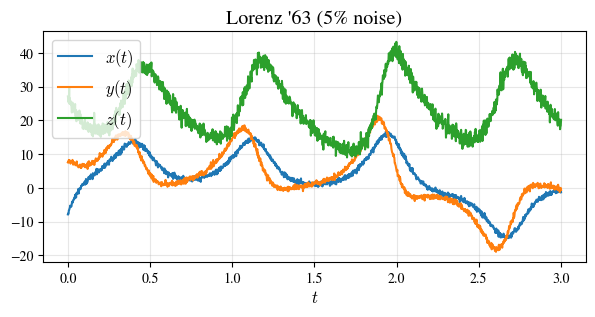

In [78]:
sigma = 10.0
rho = 28.0
beta_param = 8/3
t_np = np.linspace(0, 3, 1501)

def lorenz_rhs(t, z):
  x,y,z0 = z
  return [sigma*(y - x),
          x*(rho - z0) - y,
          x*y - beta_param*z0]

sol = solve_ivp(lorenz_rhs, (t_np[0], t_np[-1]), [-8.0, 8.0, 27.0], t_eval=t_np, rtol=1e-12, atol=1e-12, method='DOP853')

noise = 0.05
t = torch.tensor(t_np, dtype=torch.float64)
[x,y,z] = add_noise_to_states(to_torch_solution(sol), noise)

plot_states(t_np, [x,y,z], ['x','y','z'], f"Lorenz '63 ({noise*100:.0f}% noise)")

In [76]:
beta = [[0,0,0],
        [1,0,0],
        [0,1,0],
        [0,0,1],
        [2,0,0],
        [1,1,0],
        [1,0,1],
        [0,2,0],
        [0,1,1],
        [0,0,2]]

[model, ode] = fit_wsindy_system([x,y,z], t, ['x','y','z'], beta, m=[24], p=[12], s=[8], Lambda=1e-1)

100%|██████████| 1/1 [00:00<00:00, 572.05it/s]


<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [24]
p = [12]
s = [8]
yt = 20.833
yu = 0.289
Aux. scales = [0.259, 0.182]

LIBRARY
Num. query points = 182
Num. terms = 10
cond(G) = 6.547e+02

RESULTS
ODE: x_{t} = - 10.01(x) + 10.03(y)
Nonzero terms = 2
Rel. L2 error = 0.168
R^2 = 0.972
Lambda = 1.000e-01
Loss = 0.230


100%|██████████| 1/1 [00:00<00:00, 463.77it/s]


<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [24]
p = [12]
s = [8]
yt = 20.833
yu = 0.182
Aux. scales = [0.289, 0.259]

LIBRARY
Num. query points = 182
Num. terms = 10
cond(G) = 6.547e+02

RESULTS
ODE: z_{t} = - 2.68(z) + 1.00(x y)
Nonzero terms = 2
Rel. L2 error = 0.281
R^2 = 0.921
Lambda = 1.000e-01
Loss = 0.222


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>